# Analyse comparative : spaCy vs Snowball
**LO17 · TD3 — Lemmatisation et Indexation du Corpus**

Ce notebook compare les deux approches de lemmatisation appliquées au corpus ADIT filtré :
- **spaCy** (`fr_core_news_sm`) : lemmatisation linguistique contextuelle
- **Snowball** (NLTK) : racinisation par règles (algorithme de Porter adapté au français)

> **Prérequis** : avoir lancé `uv run td3` pour générer `outputs/lemmes_spacy.tsv` et `outputs/lemmes_snowball.tsv`.

---
## Configuration

In [13]:
import statistics
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

SPACY_COLOR = "#4C72B0"
SNOW_COLOR = "#DD8452"
DPI = 150


def find_project_root(start: Path, marker: str = "pyproject.toml") -> Path:
    for d in (start.resolve(), *start.resolve().parents):
        if (d / marker).exists():
            return d
    raise FileNotFoundError(f"Racine projet introuvable depuis {start}")


def load_lemma_map(path: Path) -> dict[str, str]:
    """Charge un TSV mot→lemme en dict {mot: lemme}."""
    result: dict[str, str] = {}
    for line in path.read_text(encoding="utf-8").splitlines():
        parts = line.split("\t")
        if len(parts) == 2 and parts[0] not in result:
            result[parts[0]] = parts[1]
    return result

In [14]:
project_root = find_project_root(Path.cwd())
outputs_dir = project_root / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)


def savefig(name: str) -> None:
    plt.savefig(outputs_dir / name, dpi=DPI, bbox_inches="tight")


for p in (outputs_dir / "lemmes_spacy.tsv", outputs_dir / "lemmes_snowball.tsv"):
    if not p.exists():
        raise FileNotFoundError(f"{p.name} introuvable — lancez d'abord : uv run td3")

spacy_map = load_lemma_map(outputs_dir / "lemmes_spacy.tsv")
snow_map = load_lemma_map(outputs_dir / "lemmes_snowball.tsv")

vocab = sorted(spacy_map.keys() & snow_map.keys())
spacy_forms = [spacy_map[w] for w in vocab]
snow_forms = [snow_map[w] for w in vocab]

print(f"Projet        : {project_root}")
print(f"Tokens communs: {len(vocab):,}")
print(
    "Exemples      : "
    f"{list(zip(vocab[:3], spacy_forms[:3], snow_forms[:3], strict=False))}"
)

Projet        : /home/pierre/Code/lo17/adit-corpus-indexing
Tokens communs: 14,093
Exemples      : [('aarhus', 'aarhu', 'aarhus'), ('abandonner', 'abandonner', 'abandon'), ('abandonnées', 'abandonnée', 'abandon')]


---
## 1. Statistiques générales
Taux de réduction du vocabulaire et proportion de tokens laissés inchangés par chaque méthode.

In [15]:
N = len(vocab)
n_spacy = len(set(spacy_forms))
n_snow = len(set(snow_forms))
red_spacy = (N - n_spacy) / N * 100
red_snow = (N - n_snow) / N * 100
inch_spacy = sum(w == f for w, f in zip(vocab, spacy_forms, strict=False))
inch_snow = sum(w == f for w, f in zip(vocab, snow_forms, strict=False))

rows = [
    ("Tokens uniques (entrée)", f"{N:,}", f"{N:,}"),
    ("Formes uniques (sortie)", f"{n_spacy:,}", f"{n_snow:,}"),
    ("Réduction du vocabulaire", f"{red_spacy:.1f} %", f"{red_snow:.1f} %"),
    ("Facteur de regroupement", f"{N / n_spacy:.2f}×", f"{N / n_snow:.2f}×"),
    ("Tokens inchangés", f"{inch_spacy:,}", f"{inch_snow:,}"),
    (
        "Tokens inchangés (%)",
        f"{inch_spacy / N * 100:.1f} %",
        f"{inch_snow / N * 100:.1f} %",
    ),
]

W = 34
print(f"{'Métrique':<{W}} {'spaCy':>12}  {'Snowball':>10}")
print("─" * (W + 26))
for label, vs, vn in rows:
    print(f"{label:<{W}} {vs:>12}  {vn:>10}")

Métrique                                  spaCy    Snowball
────────────────────────────────────────────────────────────
Tokens uniques (entrée)                  14,093      14,093
Formes uniques (sortie)                  10,371       8,749
Réduction du vocabulaire                 26.4 %      37.9 %
Facteur de regroupement                   1.36×       1.61×
Tokens inchangés                          7,635       3,564
Tokens inchangés (%)                     54.2 %      25.3 %


---
## 2. Réduction du vocabulaire
Snowball regroupe plus agressivement → meilleur rappel pour la RI.

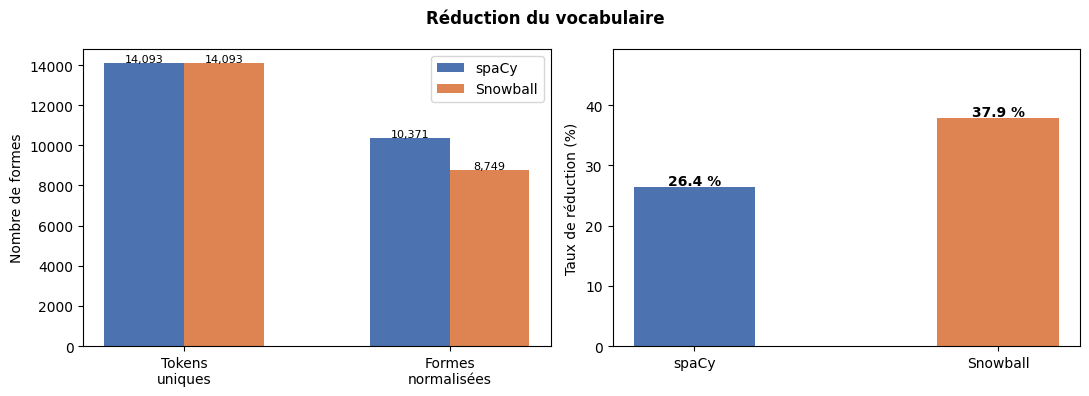

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Réduction du vocabulaire", fontweight="bold")

# Barres avant / après
w = 0.3
for i, (vals, color, label) in enumerate(
    [
        ([N, n_spacy], SPACY_COLOR, "spaCy"),
        ([N, n_snow], SNOW_COLOR, "Snowball"),
    ]
):
    xs = [j + (i - 0.5) * w for j in range(2)]
    ax1.bar(xs, vals, w, color=color, label=label)
    for x, v in zip(xs, vals, strict=False):
        ax1.text(x, v + 50, f"{v:,}", ha="center", fontsize=8)
ax1.set_xticks(range(2))
ax1.set_xticklabels(["Tokens\nuniques", "Formes\nnormalisées"])
ax1.set_ylabel("Nombre de formes")
ax1.legend()

# Taux de réduction
bars = ax2.bar(
    ["spaCy", "Snowball"],
    [red_spacy, red_snow],
    color=[SPACY_COLOR, SNOW_COLOR],
    width=0.4,
)
ax2.set_ylabel("Taux de réduction (%)")
ax2.set_ylim(0, max(red_spacy, red_snow) * 1.3)
for bar, v in zip(bars, [red_spacy, red_snow], strict=False):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{v:.1f} %",
        ha="center",
        fontweight="bold",
    )

plt.tight_layout()
savefig("plot_reduction.png")
plt.show()

---
## 3. Distribution des longueurs
Snowball produit des racines plus courtes (troncature de suffixes) que les lemmes spaCy.

In [17]:
len_tok = [len(w) for w in vocab]
len_spacy = [len(f) for f in spacy_forms]
len_snow = [len(f) for f in snow_forms]

for label, lst in [("Tokens", len_tok), ("spaCy", len_spacy), ("Snowball", len_snow)]:
    print(
        f"{label:<10}  moy={statistics.mean(lst):.2f}  "
        f"σ={statistics.stdev(lst):.2f}  min={min(lst)}  max={max(lst)}"
    )

Tokens      moy=8.09  σ=2.85  min=1  max=23
spaCy       moy=7.75  σ=2.74  min=1  max=23
Snowball    moy=6.40  σ=2.30  min=1  max=23


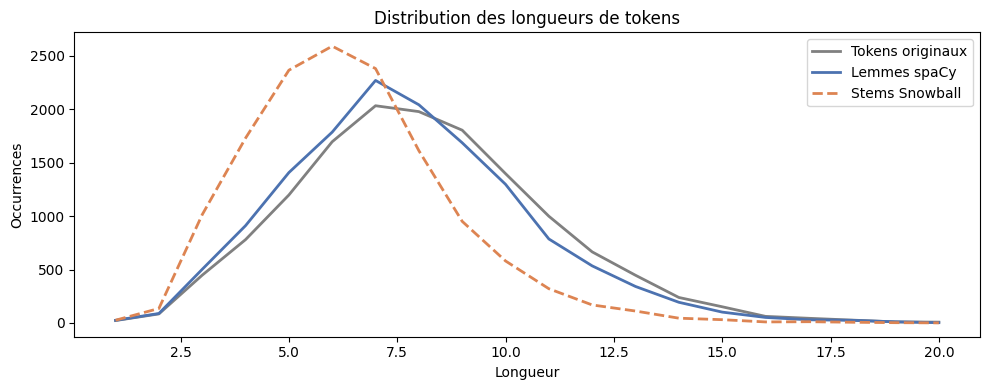

In [18]:
xs = range(1, 21)


def hist(lengths):
    c = Counter(lengths)
    return [c.get(i, 0) for i in xs]


fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(xs, hist(len_tok), color="gray", linewidth=2, label="Tokens originaux")
ax.plot(xs, hist(len_spacy), color=SPACY_COLOR, linewidth=2, label="Lemmes spaCy")
ax.plot(
    xs,
    hist(len_snow),
    color=SNOW_COLOR,
    linewidth=2,
    label="Stems Snowball",
    linestyle="--",
)
ax.set_xlabel("Longueur")
ax.set_ylabel("Occurrences")
ax.set_title("Distribution des longueurs de tokens")
ax.legend()

plt.tight_layout()
savefig("plot_longueurs.png")
plt.show()

---
## 4. Lemmes les plus fréquents
Les formes les plus présentes dans le vocabulaire normalisé — permet de repérer des lemmes vides résiduels.

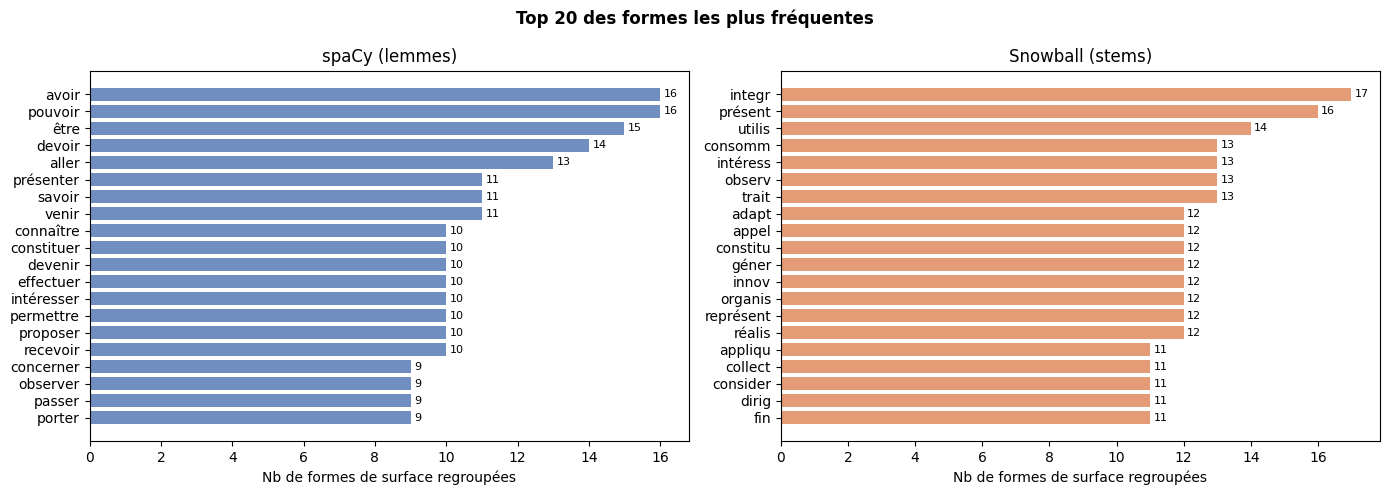

In [19]:
top_spacy = Counter(spacy_forms).most_common(20)
top_snow = Counter(snow_forms).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Top 20 des formes les plus fréquentes", fontweight="bold")

for ax, top, title, color in [
    (axes[0], top_spacy, "spaCy (lemmes)", SPACY_COLOR),
    (axes[1], top_snow, "Snowball (stems)", SNOW_COLOR),
]:
    mots, counts = zip(*top, strict=False)
    y = range(len(mots))
    ax.barh(y, counts, color=color, alpha=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(mots)
    ax.invert_yaxis()
    ax.set_xlabel("Nb de formes de surface regroupées")
    ax.set_title(title)
    for i, c in enumerate(counts):
        ax.text(c + 0.1, i, str(c), va="center", fontsize=8)

plt.tight_layout()
savefig("plot_top20.png")
plt.show()

---
## 5. Divergences entre spaCy et Snowball
Un token est *divergent* quand les deux méthodes produisent des formes différentes.

In [20]:
divergences = [
    (w, s, n) for w, s, n in zip(vocab, spacy_forms, snow_forms, strict=False) if s != n
]
nb_div = len(divergences)
pct_div = nb_div / N * 100

print(f"Divergences : {nb_div:,} / {N:,} ({pct_div:.1f} %)")
print()
print(f"{'Token':<22} {'spaCy':>16} {'Snowball':>16}")
print("─" * 56)
for w, s, n in divergences[:15]:
    print(f"{w:<22} {s:>16} {n:>16}")

Divergences : 9,563 / 14,093 (67.9 %)

Token                             spaCy         Snowball
────────────────────────────────────────────────────────
aarhus                            aarhu           aarhus
abandonner                   abandonner          abandon
abandonnées                  abandonnée          abandon
abattus                          abattu          abattus
abeille                         abeille            abeil
abeilles                        abeille            abeil
abiotique                     abiotique            abiot
ablation                       ablation            ablat
abondance                     abondance            abond
abondante                      abondant            abond
aborder                         aborder            abord
abordera                        aborder            abord
aborderont                      aborder            abord
abordé                          aborder            abord
abordée                         aborder          

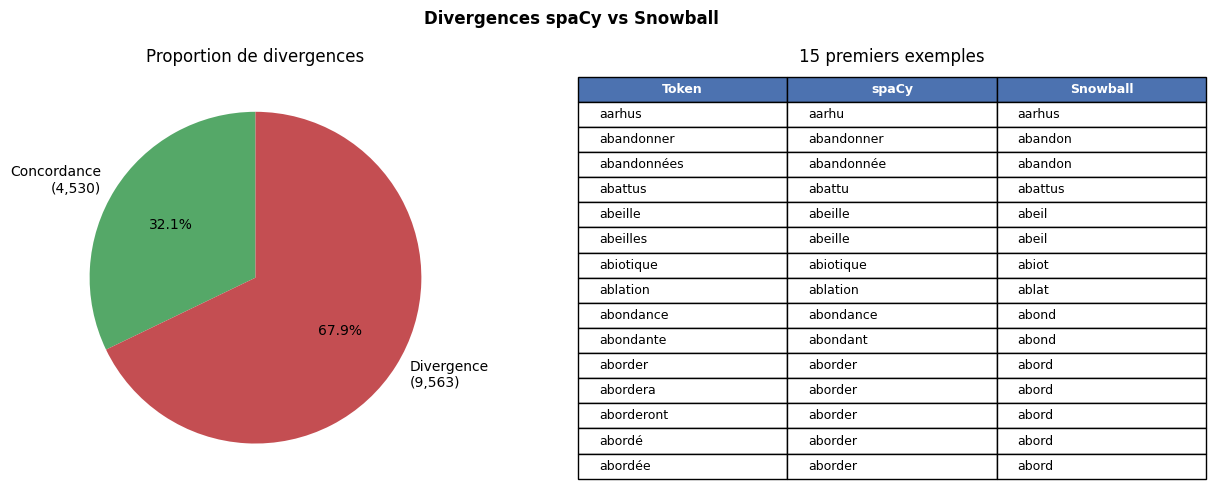

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Divergences spaCy vs Snowball", fontweight="bold")

ax1.pie(
    [N - nb_div, nb_div],
    labels=[f"Concordance\n({N - nb_div:,})", f"Divergence\n({nb_div:,})"],
    colors=["#55A868", "#C44E52"],
    autopct="%1.1f%%",
    startangle=90,
)
ax1.set_title("Proportion de divergences")

ax2.axis("off")
table = ax2.table(
    cellText=[[w, s, n] for w, s, n in divergences[:15]],
    colLabels=["Token", "spaCy", "Snowball"],
    loc="center",
    cellLoc="left",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)
for j in range(3):
    table[0, j].set_facecolor(SPACY_COLOR)
    table[0, j].set_text_props(color="white", fontweight="bold")
ax2.set_title("15 premiers exemples")

plt.tight_layout()
savefig("plot_divergences.png")
plt.show()

---
## 6. Répartition par document
Distribution du nombre de lemmes par article (source : `tokens_lemmatized.tsv`).

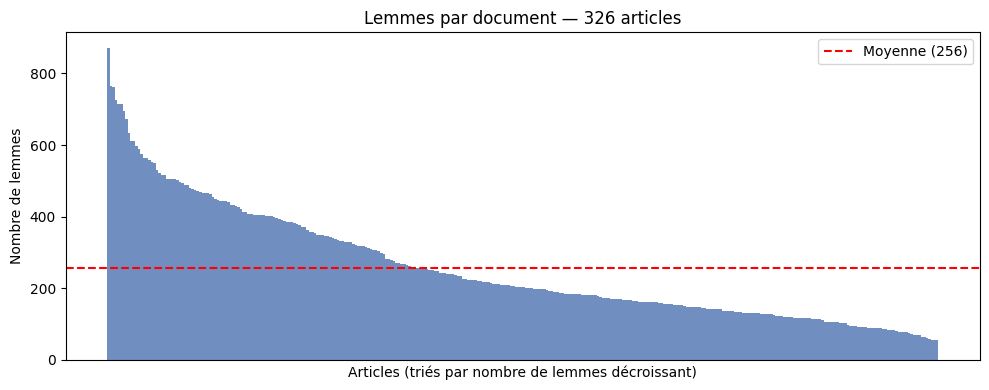

Moyenne : 255.8  |  Min : 55  |  Max : 871


In [22]:
tokens_lem_path = outputs_dir / "tokens_lemmatized.tsv"

if not tokens_lem_path.exists():
    print(f"⚠  {tokens_lem_path.name} introuvable — lancez d'abord : uv run td3")
else:
    doc_counts = Counter(
        line.split("\t")[0]
        for line in tokens_lem_path.read_text(encoding="utf-8").splitlines()
        if "\t" in line
    )
    counts = sorted(doc_counts.values(), reverse=True)
    moy = statistics.mean(counts)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(len(counts)), counts, color=SPACY_COLOR, alpha=0.8, width=1.0)
    ax.axhline(
        moy, color="red", linestyle="--", linewidth=1.5, label=f"Moyenne ({moy:.0f})"
    )
    ax.set_xlabel("Articles (triés par nombre de lemmes décroissant)")
    ax.set_ylabel("Nombre de lemmes")
    ax.set_title(f"Lemmes par document — {len(counts)} articles")
    ax.set_xticks([])
    ax.legend()

    plt.tight_layout()
    savefig("plot_tokens_par_doc.png")
    plt.show()

    print(f"Moyenne : {moy:.1f}  |  Min : {min(counts)}  |  Max : {max(counts)}")

---
## 7. Synthèse
Un taux de réduction élevé et un facteur de regroupement fort favorisent **Snowball** pour la RI.

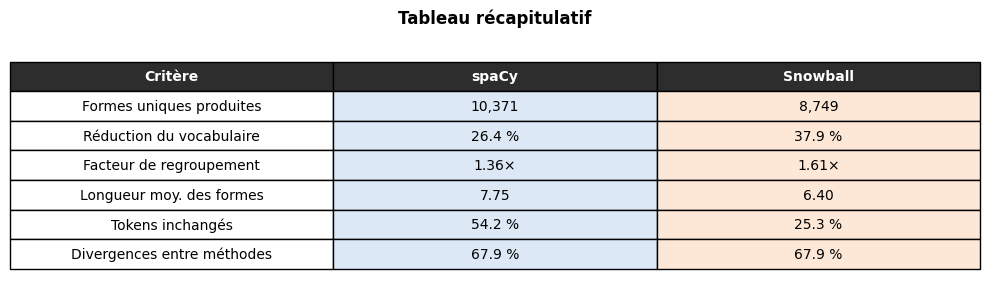

In [23]:
criteres = [
    ("Formes uniques produites", f"{n_spacy:,}", f"{n_snow:,}"),
    ("Réduction du vocabulaire", f"{red_spacy:.1f} %", f"{red_snow:.1f} %"),
    ("Facteur de regroupement", f"{N / n_spacy:.2f}×", f"{N / n_snow:.2f}×"),
    (
        "Longueur moy. des formes",
        f"{statistics.mean(len_spacy):.2f}",
        f"{statistics.mean(len_snow):.2f}",
    ),
    (
        "Tokens inchangés",
        f"{inch_spacy / N * 100:.1f} %",
        f"{inch_snow / N * 100:.1f} %",
    ),
    ("Divergences entre méthodes", f"{pct_div:.1f} %", f"{pct_div:.1f} %"),
]

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")
table = ax.table(
    cellText=[[c, vs, vn] for c, vs, vn in criteres],
    colLabels=["Critère", "spaCy", "Snowball"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)
for j in range(3):
    table[0, j].set_facecolor("#2d2d2d")
    table[0, j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(criteres) + 1):
    table[i, 1].set_facecolor("#dce8f5")
    table[i, 2].set_facecolor("#fde8d8")
ax.set_title("Tableau récapitulatif", fontsize=12, fontweight="bold", pad=20)

plt.tight_layout()
savefig("plot_recap.png")
plt.show()